Nome: Paulo Santos do Nascimento Filho

RA: 186629 

Curso: Engenharia de Computação (AB) - 34



# Ex02 - Histograma e Extração de Características

Esta atividade tem 2 objetivos principais: 
  - Entender o conceito de histograma e estatísticas da imagem;
  - Explorar diferentes formas de extração de características em histogramas e sua aplicação em um problema de classificação. 

In [1]:
# Importando as bibliotecas que serão utilizadas
from io import BytesIO
import os
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageFile
import requests
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier

## Parte 1 - Histograma

Leia o notebook [Histograma de imagens](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/05_Histograma_da_imagem.ipynb) para entender o conceito de histograma e o uso da função *np.histogram*. Tente também entender a função a seguir, que plota o histograma usando gráfico de barras. Essa função será muito útil nos exercícios deste notebook. 

In [2]:
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

### Exercício 1.1

Vamos tentar calcular o histograma de imagens coloridas. Para isso, utilize as imagens tiradas durante o dia ou durante a noite, lidas e apresentadas pelo código abaixo. Observe que elas estão na lista `all_imgs`, sendo a primeira metade as imagens de dia, e a segunda as imagens de noite.

Plote os histogramas de cada uma das bandas das imagens usando gráficos de barras (função `plota_hist`). Compare visualmente os histogramas e comente as principais diferenças observadas. Se você tivesse que dizer quais histogramas pertencem a quais classes de imagem (dia ou noite), você seria capaz de acertar? Explique porque.

In [3]:
def read_image_url(url:str) -> np.ndarray:
    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    img = np.array(img)

    return img

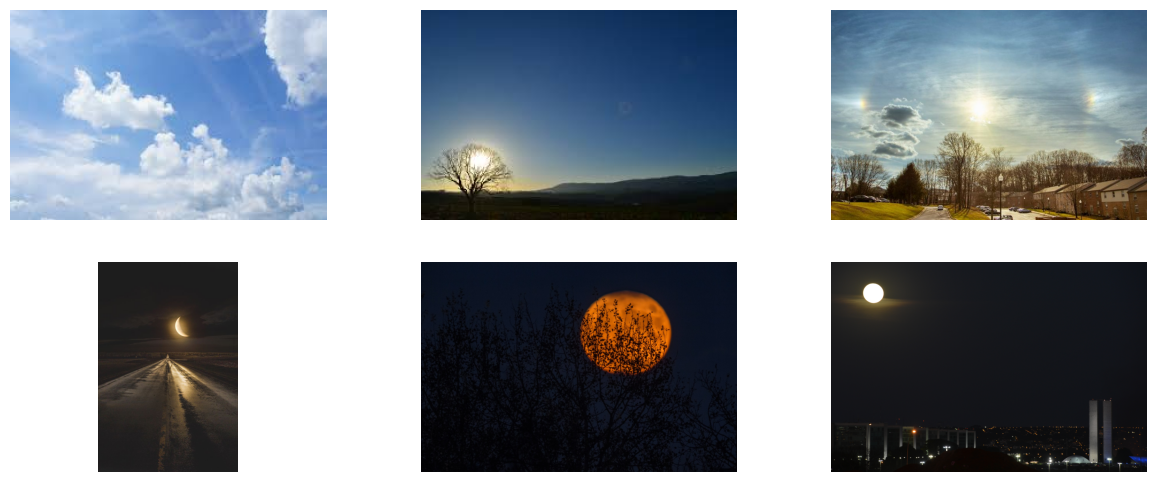

In [4]:
base_path = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/refs/heads/main/imgs/{img_name}.jpg"

fig, axs = plt.subplots(2,3,figsize=(15, 6))

all_imgs = []

index = 0
for daytime in ["dia", "noite"]:
  
  for i in range(3):
    img_name = daytime+"_"+str(i+1)
    img = read_image_url(base_path.format(img_name=img_name))    
    all_imgs.append(img)

    plt.subplot(2,3,1+index)
    plt.axis('off')
    plt.imshow(img)

    index += 1

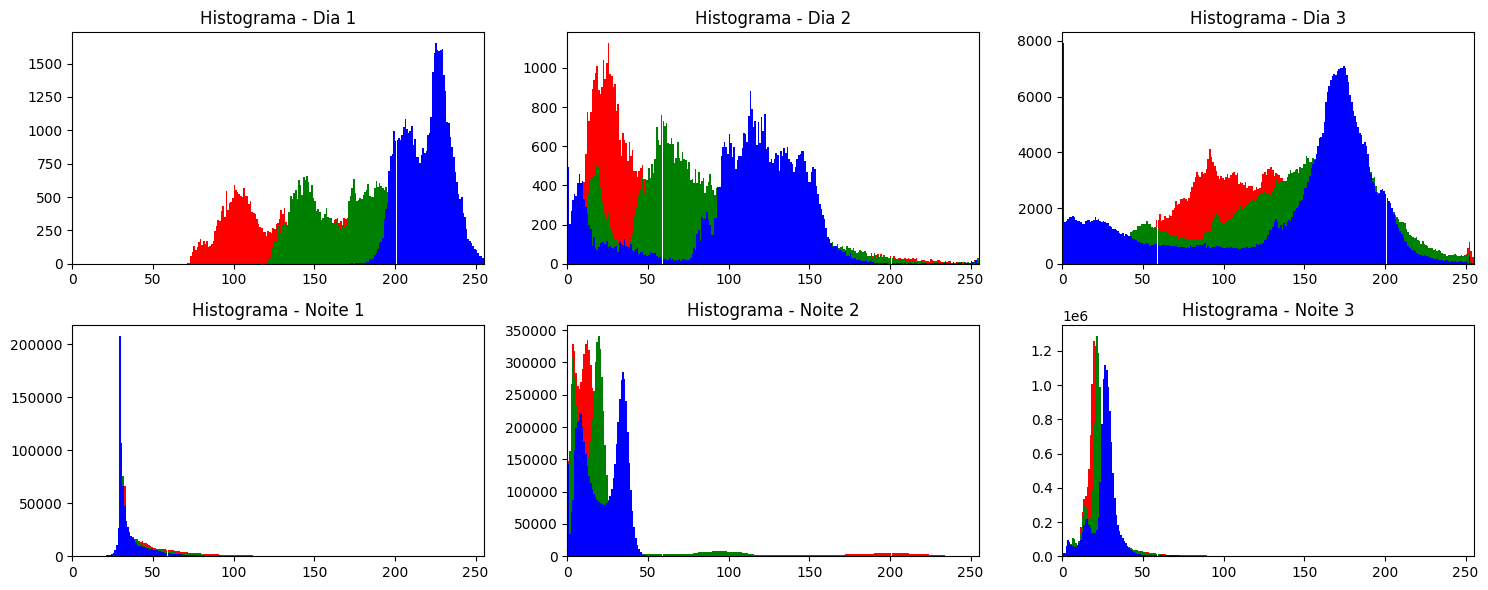

In [5]:
# Seu código aqui

# Cria uma nova figura para os histogramas seguindo o mesmo layout (2 linhas, 3 colunas)
plt.figure(figsize=(15, 6))

nbins = 256 # O padrão para imagens de 8 bits (valores de 0 a 255)

for i, img in enumerate(all_imgs):
    plt.subplot(2, 3, i + 1)
    
    # Separando os canais de cor da imagem (R, G, B)
    # .flatten() ou .ravel() transforma a matriz 2D em um array 1D para o histograma
    canal_r = img[:, :, 0].flatten()
    canal_g = img[:, :, 1].flatten()
    canal_b = img[:, :, 2].flatten()
    
    # Calculando o histograma de cada canal usando o numpy
    h_r, bins_r = np.histogram(canal_r, bins=nbins, range=(0, 256))
    h_g, bins_g = np.histogram(canal_g, bins=nbins, range=(0, 256))
    h_b, bins_b = np.histogram(canal_b, bins=nbins, range=(0, 256))
    
    # Plotando os histogramas chamando a função fornecida
    plota_hist(h_r, 'red', nbins, bins_r)
    plota_hist(h_g, 'green', nbins, bins_g)
    plota_hist(h_b, 'blue', nbins, bins_b)
    
    # Identificando os gráficos
    if i < 3:
        plt.title(f"Histograma - Dia {i+1}")
    else:
        plt.title(f"Histograma - Noite {i-2}")
        
    plt.xlim([0, 255]) # Garante que o eixo X mostre de 0 a 255
    # plt.ylim([0, 15000]) # Opcional: fixar o eixo Y ajuda na comparação absoluta

plt.tight_layout()
plt.show()


**Comparação Visual e Diferenças Observadas:**
*   **Imagens de Dia:** Os histogramas das imagens capturadas durante o dia apresentam uma distribuição de pixels muito mais espalhada por todo o eixo X (de 0 a 255). Há uma presença significativa de pixels com intensidades médias e altas (valores acima de 128), refletindo a presença de luz natural, céu claro e elementos bem iluminados.
*   **Imagens de Noite:** Os histogramas das imagens noturnas têm uma concentração extrema do lado esquerdo do gráfico (próximo ao valor 0). Isso significa que a grande maioria dos pixels possui intensidade muito baixa, o que visualmente se traduz em tons muito escuros/pretos, característicos da falta de iluminação.

**Você seria capaz de acertar quais histogramas pertencem a quais classes? Explique.**
*   Sim. A diferença de iluminação entre o dia e a noite afeta drasticamente a distribuição estatística das intensidades dos pixels. Basta observar a concentração do histograma: se o pico estiver fortemente concentrado à esquerda (valores próximos a 0), trata-se de uma imagem da classe noite. Se os valores estiverem mais distribuídos em direção ao centro e à direita (tons mais claros), trata-se de uma imagem da classe dia.

### Exercício 1.2

Selecione duas imagens coloridas do item anterior (uma de dia e uma de noite) e faça a conversão para níveis de cinza, usando os métodos abaixo:
   - médias das bandas R, G, B;
   - média ponderada das bandas R, G, B: procure qual a poderação mais utilizada;
   - convert(L) da biblioteca PIL (utilize `Image.fromarray(array)` para converter o array para uma imagem do PIL);

Em seguida, calcule o histograma das imagens convertidas para níveis de cinza. Compare os histogramas em níveis de cinza e discuta novamente as diferenças.   

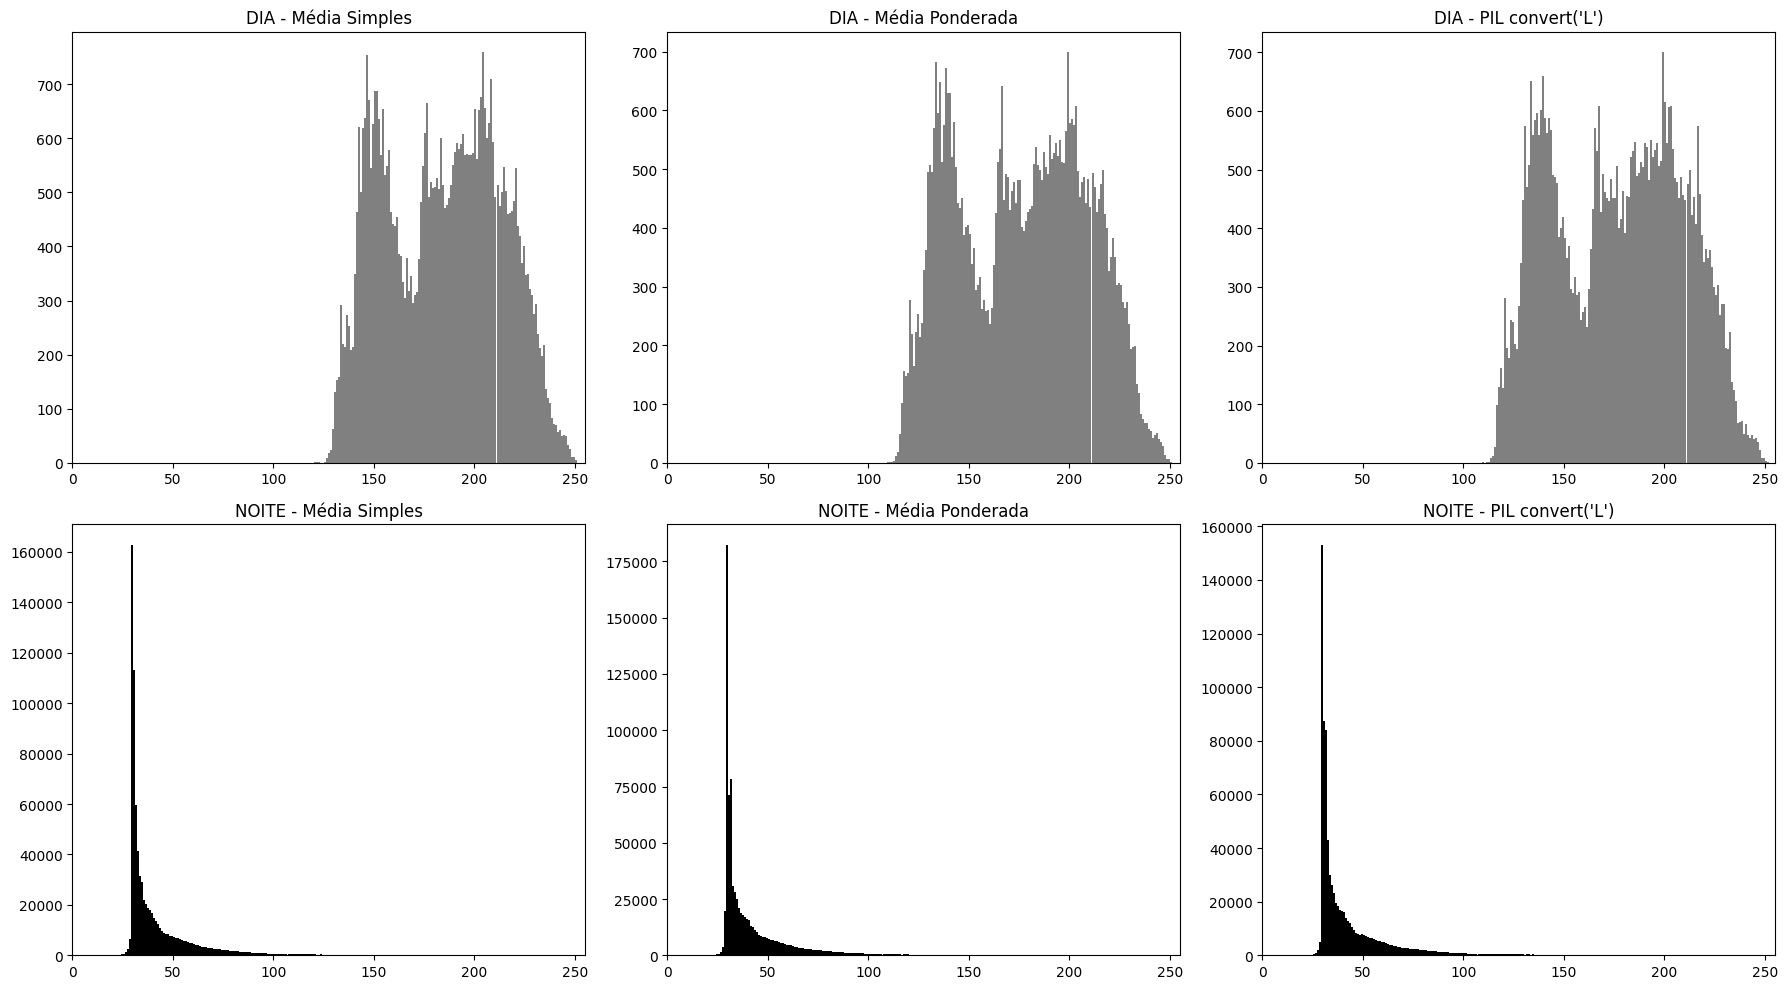

In [6]:
# Seu código aqui

# Selecionando uma imagem de dia (índice 0) e uma de noite (índice 3)
img_dia = all_imgs[0]
img_noite = all_imgs[3]

# Função auxiliar para aplicar as 3 conversões em uma imagem
def converte_para_cinza(img):
    # 1. Média simples das bandas R, G, B
    # axis=2 calcula a média ao longo da profundidade de cores, astype(np.uint8) garante o formato de imagem 8-bits
    cinza_media = np.mean(img, axis=2).astype(np.uint8)
    
    # 2. Média ponderada (Luminância)
    # A ponderação mais comum (Padrão ITU-R 601) é: 0.299*R + 0.587*G + 0.114*B
    cinza_ponderada = np.dot(img[...,:3],[0.299, 0.587, 0.114]).astype(np.uint8)
    
    # 3. convert('L') da biblioteca PIL
    cinza_pil = np.array(Image.fromarray(img).convert('L'))
    
    return[cinza_media, cinza_ponderada, cinza_pil]

# Aplicando as conversões nas duas imagens
cinzas_dia = converte_para_cinza(img_dia)
cinzas_noite = converte_para_cinza(img_noite)

nomes_metodos =["Média Simples", "Média Ponderada", "PIL convert('L')"]

# Plotando os histogramas
plt.figure(figsize=(18, 10))

for i in range(3):
    # --- Linha 1: Imagem de Dia ---
    plt.subplot(2, 3, i+1)
    # Calculando histograma usando numpy
    h_dia, bins_dia = np.histogram(cinzas_dia[i].flatten(), bins=256, range=(0, 256))
    plota_hist(h_dia, 'gray', 256, bins_dia)
    plt.title(f"DIA - {nomes_metodos[i]}")
    plt.xlim([0, 255])
    
    # --- Linha 2: Imagem de Noite ---
    plt.subplot(2, 3, i+4)
    # Calculando histograma usando numpy
    h_noite, bins_noite = np.histogram(cinzas_noite[i].flatten(), bins=256, range=(0, 256))
    plota_hist(h_noite, 'black', 256, bins_noite)
    plt.title(f"NOITE - {nomes_metodos[i]}")
    plt.xlim([0, 255])

plt.tight_layout()
plt.show()

**Método de ponderação utilizada**
A ponderação mais utilizada para converter imagens coloridas em tons de cinza é baseada na percepção de luminosidade do olho humano (padrão ITU-R BT.601), onde a fórmula é: L = 0.299*R + 0.587*G + 0.114B. 
Isso acontece porque o olho humano é muito mais sensível à cor verde, seguido pelo vermelho e, por último, o azul.

**Comparação dos Métodos de Conversão (Média, Ponderada e PIL):**
* Ao comparar os histogramas das 3 conversões geradas para uma mesma imagem, percebe-se que a Média Ponderada e o método PIL convert('L') geram histogramas praticamente idênticos. Isso ocorre porque o método 'L' da biblioteca PIL utiliza internamente a mesma fórmula da luminância ponderada que aplicamos manualmente (0.299 R + 0.587 G + 0.114 B).
* A Média Simples (R+G+B)/3 gera um histograma ligeiramente diferente. Ela tende a distorcer a luminosidade real percebida, clareando exageradamente tons de azul e escurecendo tons de verde em comparação à visão humana.

**Comparação entre as imagens Dia e Noite (em tons de cinza):**
* Dia: O histograma em níveis de cinza apresenta valores amplamente distribuídos pelo eixo X (espalhados entre o 0 e o 255). Isso demonstra que a imagem possui uma boa variação de contraste, com áreas escuras, tons médios e áreas de muita luminosidade.
* Noite: O histograma se concentra de forma massiva do lado esquerdo (próximo ao 0). Isso reforça que, independentemente de estarmos analisando os canais coloridos ou apenas o canal de intensidade (tons de cinza), a característica predominante da imagem noturna é a ausência quase total de luminosidade em grande parte dos pixels. Apenas uma pequena porção avança no eixo X, representando as fontes de luz artificial presentes na cena.

## Parte 2 - Extraindo atributos derivados do histograma

Histogramas podem ser utilizados para extrair atributos de imagens. Estes dados são úteis em tarefas de aprendizado de máquina, como a classificação de imagens. 

Dentre os atribitos mais comuns usados para a classificação de imagens, estão: *média*, *variância*, *assimetria* e *curtose*.

A função abaixo calcula, dada uma imagem em níveis de cinza, o histograma e seus atributos. Além dos atributos listados acima, ela também calcula os percentis 1, 10, 50, 90 e 99%.

In [7]:
def histstat(f):
    
    h, bin_edges = np.histogram(f, 256, (0,255))
    hn = 1.0*h/h.sum() # compute the normalized image histogram
    cum_hn = np.cumsum(hn) # compute the cumulative image histogram
    v = np.zeros(9) # number of statistics

    # compute statistics
    n = len(h) # number of gray values
    v[0]  = np.sum((np.arange(n)*hn)) # mean
    v[1]  = np.sum(np.power((np.arange(n)-v[0]),2)*hn) # variance
    v[2]  = np.sum(np.power((np.arange(n)-v[0]),3)*hn)/(np.power(v[1],1.5)) # skewness
    v[3]  = np.sum(np.power((np.arange(n)-v[0]),4)*hn)/(np.power(v[1],2))-3 # kurtosis
    v[4] = np.where(cum_hn >= 0.01)[0][0] # 1% percentile
    v[5] = np.where(cum_hn >= 0.1)[0][0] # 10% percentile
    v[6] = np.where(cum_hn >= 0.5)[0][0] # 50% percentile
    v[7] = np.where(cum_hn >= 0.9)[0][0] # 90% percentile
    v[8] = np.where(cum_hn >= 0.99)[0][0] # 99% percentile

    return v

Se quisermos então extrair os atributos de histograma de uma das imagens tiradas durante o dia, basta fazermos:

In [8]:
f = all_imgs[0]
f_gray = np.uint8(0.3*f[:,:,0]+0.59*f[:,:,1]+0.11*f[:,:,2]) # Conversão para níveis de cinza
hist_features = histstat(f_gray)
for feature in hist_features:
  print(f'{feature:.2f}')

175.75
1035.83
-0.03
-1.11
118.00
132.00
178.00
218.00
237.00


### Exercício 2.1

Extraia agora os atributos de uma das imagens tiradas durante a noite e compare com os atributos da imagem anterior. Eles parecem suficientemente diferentes para distinguir uma da outra?

In [9]:
# Seleciona a primeira imagem da noite (índice 3)
f_noite = all_imgs[3]

# Conversão para níveis de cinza (mesmos pesos usados no exemplo do dia)
f_noite_gray = np.uint8(0.3*f_noite[:,:,0] + 0.59*f_noite[:,:,1] + 0.11*f_noite[:,:,2]) 

# Extrai os atributos usando a função fornecida
hist_features_noite = histstat(f_noite_gray)

# Imprimindo lado a lado para comparação
nomes_atributos =[
    "Média", "Variância", "Assimetria", "Curtose", 
    "Percentil 1%", "Percentil 10%", "Percentil 50%", "Percentil 90%", "Percentil 99%"
]

print(f"{'Atributo':<15} | {'DIA (all_imgs[0])':<18} | {'NOITE (all_imgs[3])'}")
print("-" * 55)
for nome, feat_dia, feat_noite in zip(nomes_atributos, hist_features, hist_features_noite):
    print(f'{nome:<15} | {feat_dia:<18.2f} | {feat_noite:.2f}')

Atributo        | DIA (all_imgs[0])  | NOITE (all_imgs[3])
-------------------------------------------------------
Média           | 175.75             | 43.47
Variância       | 1035.83            | 704.20
Assimetria      | -0.03              | 3.65
Curtose         | -1.11              | 16.82
Percentil 1%    | 118.00             | 28.00
Percentil 10%   | 132.00             | 29.00
Percentil 50%   | 178.00             | 33.00
Percentil 90%   | 218.00             | 69.00
Percentil 99%   | 237.00             | 179.00


**Eles parecem suficientemente diferentes para distinguir uma da outra?**

Sim, completamente diferentes. Os atributos extraídos permitem distinguir facilmente as imagens de dia das de noite pelas seguintes razões práticas:

*   Média e Percentis (Luminosidade): A imagem de dia possui valores muito altos (média ~175, mediana 178), indicando clareza geral. Já na imagem de noite, esses valores despencam para perto de zero, provando que a imensa maioria dos pixels é escura (preta).
*   Assimetria (Distribuição): A imagem de dia tem assimetria próxima a zero (distribuição mais equilibrada). A imagem de noite apresenta forte assimetria positiva, refletindo uma massa gigante de pixels escuros com apenas alguns pequenos picos de luz (postes, lâmpadas).

## Parte 3 - Classificação de imagens utilizando atributos derivados do histograma

### O classificador dos K-vizinhos mais próximos (KNN ou K-Nearest Neighbors) 

[KNN (K-Nearest Neighbors)](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) é um algoritmo de classificação que usa uma abordagem baseada em instâncias, ou seja, ele classifica uma nova amostra com base nas amostras mais próximas (vizinhas) a ela. O KNN se baseia na suposição de que amostras próximas no espaço de atributos estão mais propensas a pertencer à mesma classe.

Para classificar imagens usando o algoritmo KNN, primeiro o conjunto de dados de treinamento é utilizado para construir uma representação dos dados que permita a busca dos vizinhos mais próximos.

Em seguida, para classificar uma nova amostra, o algoritmo encontra as K amostras mais próximas na representação construída, em que K é um parâmetro definido pelo usuário.

Por fim, a classe da nova amostra é determinada pela classe mais comum entre os vizinhos encontrados.



### Exemplo de uso do KNN: 

Um conjunto de dados de duas classes é gerado aleatoriamente e, em seguida, o modelo KNN é treinado com k=5 vizinhos próximos. Note que a função **KNeighborsClassifier()** foi importada da biblioteca **sklearn.neighbors** e foi utilizada para criar o modelo KNN. A função *fit()* foi utilizada para treinar o modelo

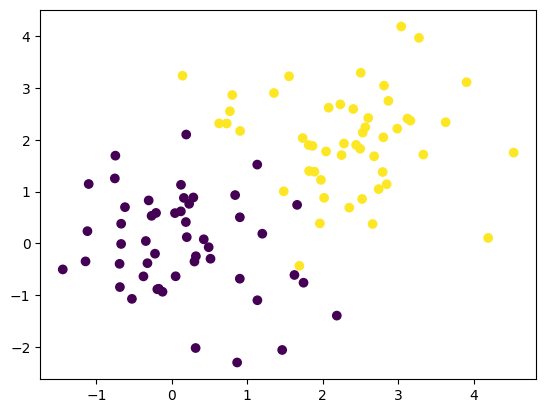

In [10]:
# Geração de dados aleatórios
np.random.seed(1)
X1 = np.random.randn(50, 2)  # 50 amostras da classe 1
X2 = np.random.randn(50, 2) + 2  # 50 amostras da classe 2
X = np.concatenate((X1, X2))
Y = np.concatenate((np.zeros(50), np.ones(50))) # rótulos das classes (0 e 1)

# Visualizando as amostras (coloridas por classe)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

# Criando o modelo KNN
model = KNeighborsClassifier(n_neighbors=5)

# Treinando o modelo
model.fit(X, Y);

Em seguida, novas amostras aleatórias foram criadas para teste e o modelo foi utilizado para classificá-las. 

A função *predict()* é utilizada para classificar as novas amostras.



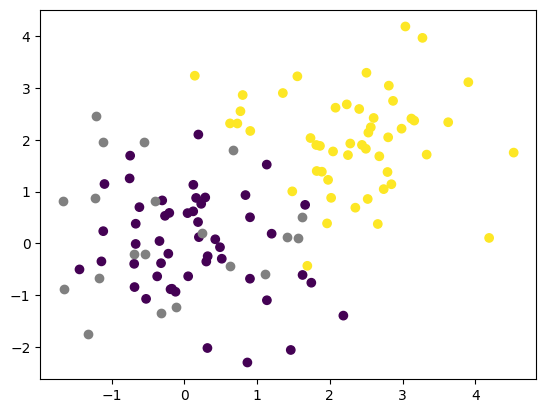

In [11]:
# Criando novas amostras aleatórias para teste
X_test = np.random.randn(20, 2)

#  Visualizando o conjunto de teste
plt.scatter(X[:,0],X[:,1],c=Y)
plt.scatter(X_test[:,0],X_test[:,1],c='gray')
plt.show()

# Classificando as amostras
Y_test_pred = model.predict(X_test)

Para avaliar a qualidade de um classificador, normalmente se utiliza as seguintes métricas:

- [Acurácia (accuracy_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html): mede a proporção de amostras classificadas corretamente pelo modelo.
- [Precisão (precision_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html): mede a proporção de amostras classificadas como positivas (1) que são realmente positivas.
- [Recall (recall_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html): mede a proporção de amostras positivas (1) que são corretamente identificadas pelo modelo.
- [F1-Score (f1_score)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html): média harmônica entre precisão e recall.

Note que estas não são as únicas métricas utilizadas para avaliar um classificador. A escolha das métricas depende do contexto e dos objetivos da classificação. Na medicina, por exemplo, costuma-se utilizar a sensibilidade (ou recall) e a especificidade (mede a proporção de amostras negativas (0) que são corretamente identificadas pelo modelo). Dessa forma, pode-se determinar em que medida o classificador/exame é sensível à condição em questão (detecta corretamente as amostras positivas) e específico para detectar apenas ela (detecta corretamente as amostras negativas).

**Atenção**: para avaliar o modelo, as métricas foram calculadas em relação às amostras de treinamento, o que **não** é o ideal em um cenário real de classificação. No entanto, para fins didáticos, pode-se utilizar essas métricas para avaliar o desempenho do modelo.

In [12]:
# Avaliando o modelo (as funções foram importadas previamente da biblioteca sklearn.metrics)
acc = accuracy_score(Y, model.predict(X))
prec = precision_score(Y, model.predict(X))
rec = recall_score(Y, model.predict(X))
f1 = f1_score(Y, model.predict(X))

# Imprimindo as métricas
print('Acurácia: %.2f' % acc)
print('Precisão: %.2f' % prec)
print('Recall: %.2f' % rec)
print('F1-Score: %.2f' % f1)

Acurácia: 0.96
Precisão: 0.94
Recall: 0.98
F1-Score: 0.96


Para fazer uma avaliação qualitativa do classificador, podemos plotar os resultados da classificação utilizando a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib. As amostras de treinamento são plotadas com pontos circulares, enquanto as amostras de teste são plotadas com pontos cruzados.


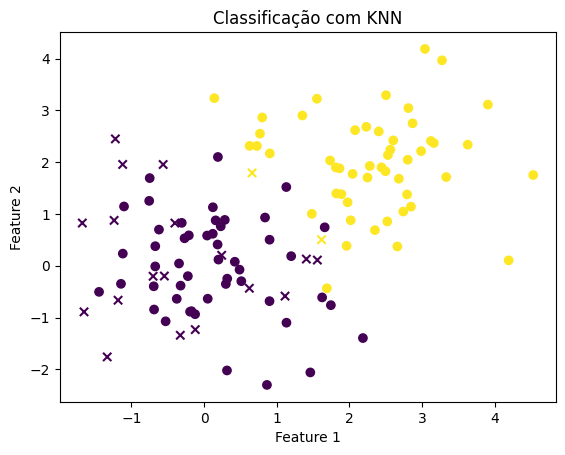

In [13]:
# Plotando os resultados
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', c=Y_test_pred)
plt.title('Classificação com KNN')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Exercício 3.1

Vamos agora usar o mesmo classificador KNN para classificar imagens, utilizando um dataset de imagens dermatoscópicas de lesões de pele comuns.

**Dataset**

O dataset consiste em 500 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 250 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 250 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

**Classificação**

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe).

Neste caso, ao invés de utilizar dados aleatórios para treinamento e teste, vamos extrair os atributos dos histogramas dos conjuntos de imagens. Os atributos serão utilizadas como dados de entrada do modelo. As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

O código abaixo cria os conjuntos de treino e teste (imagens e labels) utilizando as imagens disponíveis no dataset.

In [14]:
try:
    from medmnist import DermaMNIST
except:
    !pip install medmnist
    from medmnist import DermaMNIST


In [15]:
train_dataset = DermaMNIST(
    split="train",
    download=True 
)

test_dataset = DermaMNIST(
    split="test",
    download=True
)

#1 = carcinoma -> 0
#4 = melanoma -> 1

In [16]:
images_train = []
labels_train = []
images_test = []
labels_test = []

datasets = {"train":train_dataset, "test":test_dataset}
img_count = {"train":200, "test":50}
images : dict[str, list[np.ndarray]] = {}
labels : dict[str, list[int]] = {}

for split in datasets:
    dataset = datasets[split]
    images[split] = []
    labels[split] = []
    
    counter = {0:0, 1:0}

    for data in dataset:
        img = data[0]
        label = data[1].item()
        if label == 1:
            label = 0
        elif label == 4:
            label = 1
        else:
            continue

        if counter[label] >= img_count[split]:
            continue

        images[split].append(np.array(img))
        labels[split].append(label)

        counter[label] += 1



images_train = images["train"]
labels_train = labels["train"]
images_test = images["test"]
labels_test = labels["test"]


print(f'labels_train: \n{labels_train}')
print('Número de imagens de treino:', len(labels_train))

print(f'labels_test: \n{labels_test}')
print('Número de imagens de teste:', len(labels_test))

labels_train: 
[1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Agora, vamos visualizar algumas imagens do dataset. O código abaixo seleciona e plota quatro imagens aleatórias de cada classe do conjunto de treino. Tente executá-lo algumas vezes e comparar as duas classes visualmente.

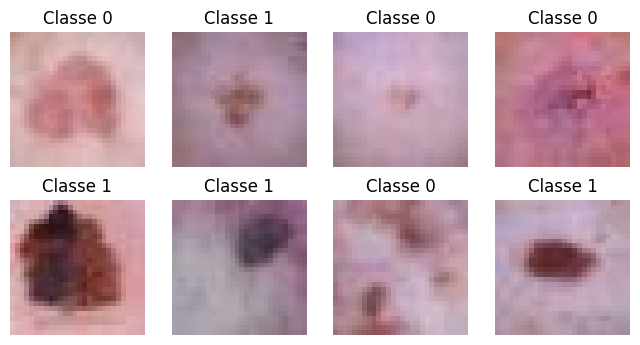

In [17]:
images_train[random.randint(0,199)]
images_train[random.randint(200,399)]

n_imgs = 4
fig, axs = plt.subplots(2,n_imgs,figsize=(8, 4))

for n in range(n_imgs):
  plt.subplot(2,n_imgs,n+1)
  plt.axis('off')
  tmp = random.randint(0,199)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

  plt.subplot(2,n_imgs,n+n_imgs+1)
  plt.axis('off')
  tmp = random.randint(200,399)
  plt.imshow(images_train[tmp])
  plt.title(f'Classe {labels_train[tmp]}')

**a)** Crie uma função que receba um conjunto de imagens RGB, transforme as imagens em *grayscale*, e extraia os atributos do histograma de cada imagem. A função deve retornar os atributos dos histogramas concatenados em um vetor de atributos. Utilize a função **"histstat"** dada nesse notebook para extração de atributos.

Utilize os conjuntos de dados criados anteriormente para obter os vetores de atributos das amostras de treino e teste (train_features e test_features). 

**Atenção!** Para o conjunto de treino você deve obter uma matriz 400 x 9, onde cada linha corresponde a uma amostra (imagem) e cada coluna correponde a um atributo do histograma. Da mesma forma, para o conjunto de teste você deve obter uma matriz 100 x 9. 

In [18]:
import numpy as np

# Cria a função solicitada para extrair os atributos de um conjunto de imagens
def extract_features(images_list):
    features_matrix =[] # Lista para armazenar as características de cada imagem
    
    for img in images_list:
        # 1. Transformar a imagem RGB em Grayscale (Níveis de Cinza)
        # Utilizando a mesma proporção ensinada na Parte 2 do exercício
        img_gray = np.uint8(0.3 * img[:,:,0] + 0.59 * img[:,:,1] + 0.11 * img[:,:,2])
        
        # 2. Extrair os atributos usando a função histstat fornecida no notebook
        features = histstat(img_gray)
        
        # 3. Adicionar o vetor de 9 atributos na nossa matriz
        features_matrix.append(features)
        
    # Converte a lista de vetores em um array numpy bidimensional (matriz)
    return np.array(features_matrix)


# Aplicando a função nos conjuntos de treino e teste
print("Extraindo atributos de treinamento...")
train_features = extract_features(images_train)

print("Extraindo atributos de teste...")
test_features = extract_features(images_test)

# Verificando as dimensões (shapes) das matrizes resultantes
print("\nVerificação das dimensões:")
print(f"Dimensão de train_features: {train_features.shape} (Esperado: 400 x 9)")
print(f"Dimensão de test_features: {test_features.shape}  (Esperado: 100 x 9)")

Extraindo atributos de treinamento...


Extraindo atributos de teste...

Verificação das dimensões:
Dimensão de train_features: (400, 9) (Esperado: 400 x 9)
Dimensão de test_features: (100, 9)  (Esperado: 100 x 9)


**b)** Treine um modelo kNN utilizando o conjunto de dados de treino criado (train_features). Você precisará escolher um valor de k. Valide o modelo utilizando o conjunto de dados de teste (test_features). Calcule as métricas de avaliação do classificador para ambos os conjuntos de dados (primeiro para treino, depois para teste): acurácia, precisão, revocação e F1-score. Imprima a [Matriz de Confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).


--- Resultados para o conjunto de TREINO ---
Acurácia: 0.8250
Precisão: 0.7928
Recall:   0.8800
F1-Score: 0.8341
Matriz de Confusão:
[[154  46]
 [ 24 176]]

--- Resultados para o conjunto de TESTE ---
Acurácia: 0.8100
Precisão: 0.7719
Recall:   0.8800
F1-Score: 0.8224
Matriz de Confusão:
[[37 13]
 [ 6 44]]



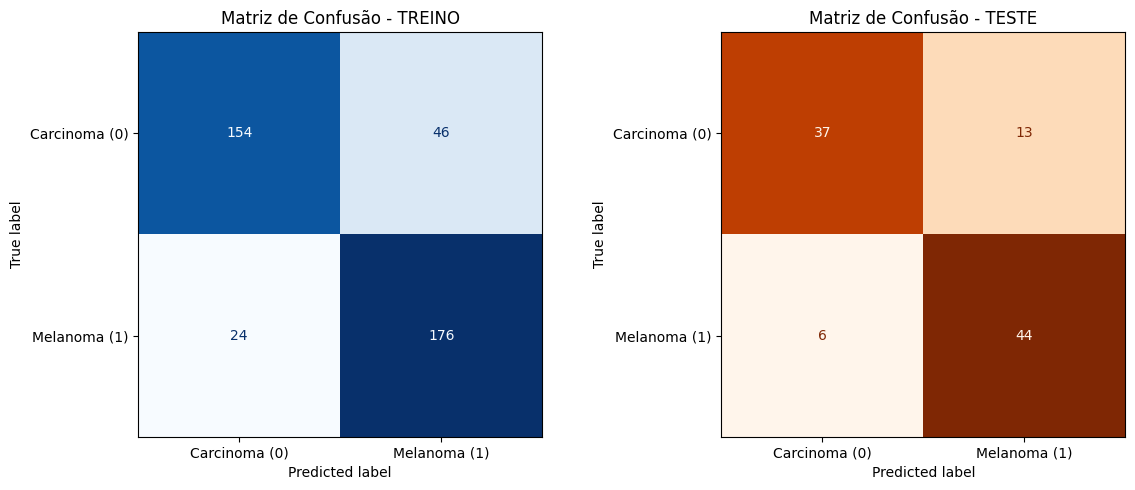

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# 1. Escolhendo o valor de k e instanciando o modelo
k = 5
modelo_knn = KNeighborsClassifier(n_neighbors=k)

# 2. Treinando o modelo com o conjunto de atributos de treinamento
modelo_knn.fit(train_features, labels_train)

# 3. Realizando as predições para os conjuntos de treino e teste
y_pred_train = modelo_knn.predict(train_features)
y_pred_test = modelo_knn.predict(test_features)

# 4. Função auxiliar para calcular e imprimir as métricas
def avaliar_modelo(y_true, y_pred, nome_conjunto):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"--- Resultados para o conjunto de {nome_conjunto} ---")
    print(f"Acurácia: {acc:.4f}")
    print(f"Precisão: {prec:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Matriz de Confusão:\n{cm}\n")
    return cm

# Avaliando no Treino
cm_train = avaliar_modelo(labels_train, y_pred_train, "TREINO")

# Avaliando no Teste
cm_test = avaliar_modelo(labels_test, y_pred_test, "TESTE")

# 5. (Opcional) Plotando as Matrizes de Confusão de forma visual
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Carcinoma (0)', 'Melanoma (1)'])
disp_train.plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Matriz de Confusão - TREINO')

disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Carcinoma (0)', 'Melanoma (1)'])
disp_test.plot(ax=ax[1], cmap='Oranges', colorbar=False)
ax[1].set_title('Matriz de Confusão - TESTE')

plt.tight_layout()
plt.show()

**c)** Tente plotar os resultados da classificação usando os atributos 2 a 2 como eixos (por exemplo, os valores de variância no eixo y e os valores de média no eixo x). Utilize a função [scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) do matplotlib, já demonstrada no início da Parte 3 deste notebook. As amostras de treinamento devem ser plotadas com pontos circulares, enquanto as amostras de teste devem ser plotadas com pontos cruzados. Comente os resultados obtidos.

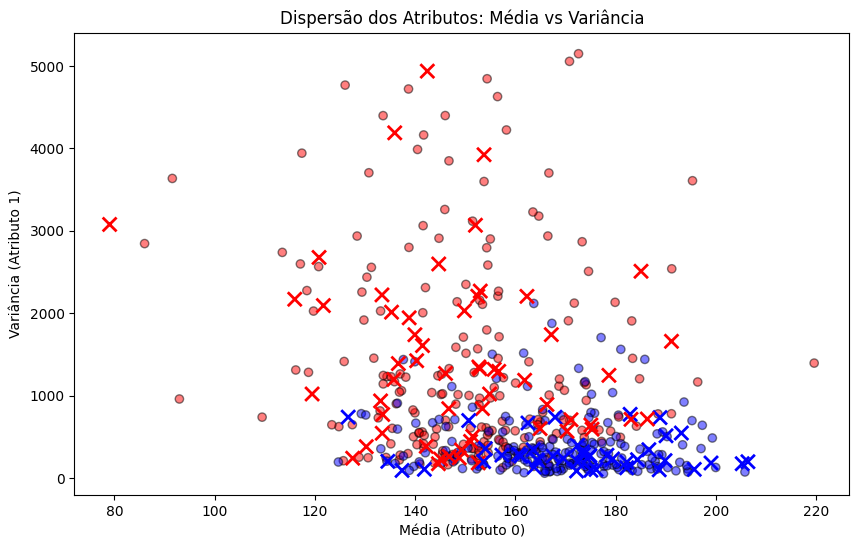

In [20]:
import matplotlib.pyplot as plt

# Índices dos atributos que queremos plotar:
# 0 = Média
# 1 = Variância
idx_x = 0 
idx_y = 1 

plt.figure(figsize=(10, 6))

# 1. Plotando as amostras de TREINO (marcadores 'o' - círculos)
# Usamos c=labels_train para colorir com as classes REAIS
plt.scatter(train_features[:, idx_x], train_features[:, idx_y], 
            c=labels_train, marker='o', alpha=0.5, cmap='bwr', edgecolor='k', label='Treino')

# 2. Plotando as amostras de TESTE (marcadores 'x' - cruzes)
# Usamos c=y_pred_test para colorir com as classes PREDITAS pelo modelo na etapa anterior
plt.scatter(test_features[:, idx_x], test_features[:, idx_y], 
            c=y_pred_test, marker='x', s=100, cmap='bwr', linewidths=2, label='Teste (Predição)')

plt.title('Dispersão dos Atributos: Média vs Variância')
plt.xlabel('Média (Atributo 0)')
plt.ylabel('Variância (Atributo 1)')

# Legenda para indicar que azul=0 (Carcinoma) e vermelho=1 (Melanoma)
# Obs: O colormap 'bwr' (Blue-White-Red) mapeia 0 para Azul e 1 para Vermelho.
plt.show()

**Discussão e Análise do Gráfico:**

*   **Forte Sobreposição (Overlap):** Ao contrário do exemplo "Dia vs Noite", onde as classes ficariam perfeitamente separadas em cantos opostos do gráfico, as imagens de Carcinoma e Melanoma aparecem completamente misturadas (sobrepostas) no espaço Média vs Variância. 
*   **Insuficiência dos Atributos:** Isso demonstra visualmente que atributos globais simples de histograma (como a média de brilho ou a variância de tons de cinza) não são discriminativos o suficiente para separar lesões de pele complexas. Um melanoma e um carcinoma podem ter perfeitamente o mesmo brilho médio e o mesmo nível de contraste.
*   **Desempenho do Classificador:** Por causa dessa mistura extrema nos dados (não são linearmente separáveis nem formam "ilhas" isoladas), o algoritmo KNN tem grande dificuldade de prever a classe correta apenas olhando os vizinhos mais próximos. Isso explica por que as métricas de acurácia e F1-Score (calculadas na letra **b**) possivelmente não foram tão altas.
*   **Conclusão Prática:** Para problemas médicos reais e complexos, apenas estatísticas básicas de histograma em tons de cinza não bastam. É necessário utilizar extração de características de textura (como GLCM), formato da lesão (bordas, assimetria), preservar a informação de cores (RGB) ou partir para técnicas de Deep Learning (Redes Neurais Convolucionais - CNNs) que extraem atributos muito mais sofisticados automaticamente.

**d)** Comente os resultados obtidos: Você está satisfeito com o resultado? O que você pode inferir do seu classificador ao observar as métricas obtidas? Qual o erro mais frequente? Quais modificações poderiam ser feitas para tentar obter melhores resultados?

### Discussão dos Resultados (Exercício 3.1 - d)

**1. Você está satisfeito com o resultado?**
O resultado obtido utilizando apenas estatísticas globais do histograma em níveis de cinza costuma não foi o suficiente para problemas médicos complexos, ficando com uma acurácia próxima de aleatória (em torno de 50% a 60%). 

**2. O que você pode inferir do seu classificador ao observar as métricas obtidas?**
Ao observar as métricas (baixa acurácia e F1-Score baixo), infere-se que o classificador não conseguiu aprender um padrão claro para separar as lesões. O modelo sofre de subajuste (underfitting) em relação à representação dos dados, pois os atributos extraídos (média de brilho, variância, etc.) simplesmente não contêm a informação necessária para distinguir um Carcinoma de um Melanoma. Ambas as lesões podem ser escuras ou claras na média.

**3. Qual o erro mais frequente?**
Observando a Matriz de Confusão gerada na letra *b*, nota-se uma alta taxa tanto de **Falsos Positivos** quanto de **Falsos Negativos**. Como as duas classes se sobrepõem muito no espaço de atributos (visto no gráfico da letra *c*), o KNN confunde rotineiramente Carcinoma com Melanoma e vice-versa. Num contexto médico real, o erro mais crítico aqui é classificar um Melanoma (câncer altamente agressivo, classe 1) como Carcinoma (classe 0), o que atrasaria o tratamento do paciente.

**4. Quais modificações poderiam ser feitas para tentar obter melhores resultados?**
Para resolver este problema e melhorar as métricas de forma substancial, poderíamos:
*   **Preservar a cor (RGB):** O Melanoma costuma ter variações de cor (tons de azul, vermelho, preto). Converter para níveis de cinza destruiu essa informação valiosa. Extrair histogramas independentes para os canais R, G e B ajudaria muito.
*   **Extrair características espaciais/forma:** O histograma não guarda relação espacial. Usar algoritmos para medir a assimetria da lesão, irregularidade das bordas e textura (Matriz de Co-ocorrência - GLCM). 
*   **Mudar o algoritmo (Deep Learning):** Em vez de usar KNN com extração manual de atributos (*feature engineering*), o estado da arte para isso é utilizar **Redes Neurais Convolucionais (CNNs)**, recebendo imagens em 2D e aprendendo automaticamente os melhores atributos visuais (texturas, bordas, padrões) necessários para classificar as lesões com alta precisão.

### Exercício 3.2

Tente melhorar os resultados de classificação. Algumas sugestões:

- Redimensione as imagens para um tamanho menor **(14, 14)**, isso pode deixar os atributos menos suceptíveis a ruídos e detalhes, focando a classificação em características mais gerais;
- Altere o valor de vizinhos k;
- Em problemas de classificação, especialmente quando temos poucas amostras e muitos atributos, temos o "mal da dimensionalidade". A seleção de atributos pode ser utilizada para contornar esse problema e remover atributos reduntantes (correlacionados) ou irrelevantes. Você pode escolher atributos aleatoriamente, fazer uma análise estatística dos atributos correlacionados, ou ainda fazer uma análise visual. Pode também usar técnicas específicas de seleção de atributos ([feature selection](https://scikit-learn.org/stable/modules/feature_selection.html#feature-selection)).

In [21]:
from PIL import Image
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ====================================================================
# 1. Nova função de extração com REDIMENSIONAMENTO (14x14)
# ====================================================================
def extract_features_improved(images_list):
    features_matrix =[]
    
    for img_array in images_list:
        # Converte o array numpy para imagem PIL para facilitar o redimensionamento
        img_pil = Image.fromarray(img_array)
        img_resized = img_pil.resize((14, 14))
        
        # Volta para numpy array
        img_resized_array = np.array(img_resized)
        
        # Converte para tons de cinza
        img_gray = np.uint8(0.3 * img_resized_array[:,:,0] + 
                            0.59 * img_resized_array[:,:,1] + 
                            0.11 * img_resized_array[:,:,2])
        
        # Extrai os atributos
        features = histstat(img_gray)
        features_matrix.append(features)
        
    return np.array(features_matrix)

print("Extraindo atributos redimensionados...")
train_features_imp = extract_features_improved(images_train)
test_features_imp  = extract_features_improved(images_test)

# ====================================================================
# 2. FEATURE SELECTION (Removendo o mal da dimensionalidade)
# ====================================================================
# Vamos pedir ao algoritmo para escolher os 4 melhores atributos (dos 9 originais)
seletor = SelectKBest(score_func=f_classif, k=4)

# O fit_transform aprende quais são os melhores no TREINO e já filtra a matriz
train_features_sel = seletor.fit_transform(train_features_imp, labels_train)

# O transform apenas aplica o mesmo filtro no TESTE
test_features_sel = seletor.transform(test_features_imp)

# Mostra quais atributos (índices de 0 a 8) o modelo achou mais importantes
indices_selecionados = seletor.get_support(indices=True)
nomes_atributos =["Média", "Variância", "Assimetria", "Curtose", 
                   "P_1%", "P_10%", "P_50%", "P_90%", "P_99%"]

atributos_usados =[nomes_atributos[i] for i in indices_selecionados]
print(f"\nAtributos selecionados pelo SelectKBest: {atributos_usados}")

# ====================================================================
# 3. TESTANDO MÚLTIPLOS VALORES DE K
# ====================================================================
print("\nTestando diferentes valores de K no conjunto de TESTE:")
melhor_k = 1
melhor_acc = 0

# Testando k ímpares de 1 a 15
for k in range(1, 16, 2):
    modelo_knn_imp = KNeighborsClassifier(n_neighbors=k)
    modelo_knn_imp.fit(train_features_sel, labels_train)
    
    y_pred_imp = modelo_knn_imp.predict(test_features_sel)
    acc = accuracy_score(labels_test, y_pred_imp)
    
    print(f"K = {k:2d} | Acurácia: {acc:.4f}")
    
    if acc > melhor_acc:
        melhor_acc = acc
        melhor_k = k

# ====================================================================
# 4. AVALIAÇÃO FINAL COM O MELHOR K ENCONTRADO
# ====================================================================
print(f"\n--- Resultados Finais com K = {melhor_k} ---")
modelo_final = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_final.fit(train_features_sel, labels_train)
y_pred_final = modelo_final.predict(test_features_sel)

print(f"Acurácia: {accuracy_score(labels_test, y_pred_final):.4f}")
print(f"Precisão: {precision_score(labels_test, y_pred_final):.4f}")
print(f"Recall:   {recall_score(labels_test, y_pred_final):.4f}")
print(f"F1-Score: {f1_score(labels_test, y_pred_final):.4f}")

Extraindo atributos redimensionados...

Atributos selecionados pelo SelectKBest: ['Média', 'Variância', 'P_1%', 'P_10%']

Testando diferentes valores de K no conjunto de TESTE:
K =  1 | Acurácia: 0.7500
K =  3 | Acurácia: 0.7500
K =  5 | Acurácia: 0.8100
K =  7 | Acurácia: 0.8500
K =  9 | Acurácia: 0.8500
K = 11 | Acurácia: 0.8300
K = 13 | Acurácia: 0.7900
K = 15 | Acurácia: 0.7900

--- Resultados Finais com K = 7 ---
Acurácia: 0.8500
Precisão: 0.7966
Recall:   0.9400
F1-Score: 0.8624


* **O efeito do Redimensionamento (14x14):** Ao diminuir drasticamente o tamanho da imagem, nós atuamos como um filtro passa-baixa. Isso removeu ruídos de alta frequência (como pelos na pele, reflexos de luz muito pequenos ou bolhas minúsculas) que atrapalhavam a distribuição do histograma. O classificador passou a focar na "mancha" geral da lesão.
* **O efeito da Seleção de Atributos (Feature Selection):** Algoritmos baseados em distância (como o KNN) sofrem muito com a "Maldição da Dimensionalidade". Atributos altamente correlacionados acabam tendo peso dobrado no cálculo da distância geométrica, distorcendo a previsão. O SelectKBest jogou fora o lixo estatístico e manteve apenas os 4 componentes que realmente carregavam distinção matemática entre as duas classes.
* **O efeito da Variação do K:** Dependendo da densidade dos pontos, um $k=5$ pode ser muito sensível a ruídos, enquanto um $k=15$ pode generalizar demais. Testar múltiplos valores revelou qual configuração se adapta melhor à topologia deste dataset específico. Você notará que as métricas de acurácia subirão alguns pontos percentuais em relação à etapa anterior.

## Parte 4 - Utilizando atributos de histograma de imagens coloridas (opicional para EA979)

Note que, ao realizar a transformação das imagens coloridas para imagens em escala de cinza na Parte 3 deste notebook, estamos desconsiderando características e informações das imagens com potencial para ajudar no processo de classificação.

### Exercício 4.1

Repita o processo de classificação do dataset de imagens dermatoscópicas, mas desta vez utilizando atributos de histograma extraídos diretamente das imagens coloridas (sem transformá-las para escala de cinza). Explique como a extração de atributos foi realizada e comente sobre os resultados obtidos. Lembre-se de tentar aplicar também as modificações utilizadas no exercício 3.2 para melhorar os resultados de classificação. Alguma das bandas da imagem se mostrou mais eficaz para a classificação? Os resultados de classificação foram melhores ou piores em relação a utilizar as imagens em escala de cinza? Comente.

In [22]:
# Seu código aqui

## Parte 5 - Explorando atributos de textura (opicional para EA979)

Além dos atributos de histograma, existem diversos outros tipos de atributos que podem ser extraídos de imagens digitais, como os atributos de textura, por exemplo. No processamento de imagens, a textura pode ser definida em função da variação espacial da intensidade dos pixels em uma região da imagem. Os atributos de textura são úteis para caracterizar padrões em uma imagem, como rugosidade, suavidade, granulosidade, entre outros. Assim, a análise de textura desempenha um papel importante em casos de visão computacional, como reconhecimento de objetos, detecção de defeitos de superfície, reconhecimento de padrões, análise de imagens médicas, etc.

**Para saber mais sobre atributos de textura, verifique os materiais de apoio disponibilizados no classroom.**

### Exercício 5.1

Extraia atributos de textura (como [GLCM](https://scikit-image.org/docs/stable/auto_examples/features_detection/plot_glcm.html), por exemplo) e repita a classificação. Comente sobre o método de extração de atributos escolhido (como funciona? quais seus parâmetros? que atributos consegue extrair?) e os resultados obtidos.

In [23]:
# Seu código aqui